In [12]:
from roboflow import Roboflow
import requests

api_key = "oM5HmQvpmTuQl6vYcko2"

url = f"https://api.roboflow.com/?api_key={api_key}"

response = requests.get(url)

print(response.json())

{'welcome': 'Welcome to the Roboflow API.', 'instructions': 'You are successfully authenticated.', 'docs': 'https://docs.roboflow.com', 'workspace': 'hammad-ahmed', 'workspaceId': 'Joiqvl9Xb2N2tzMS6m7fFIM8YL13'}


In [13]:
from roboflow import Roboflow

rf = Roboflow(api_key="oM5HmQvpmTuQl6vYcko2")

workspace = rf.workspace("hammad-ahmed")

print(workspace.project_list)

loading Roboflow workspace...
[{'id': 'hammad-ahmed/parking-lot-j4ojc-yfnel', 'type': 'object-detection', 'name': 'parking lot', 'created': 1725459031.944, 'updated': 1785133488.841, 'images': 913, 'unannotated': 0, 'annotation': 'cars-free', 'versions': 1, 'public': True, 'multilabel': False, 'license': 'CC BY 4.0', 'splits': {'valid': 116, 'test': 86, 'train': 711}, 'colors': {'car': '#C7FC00', 'free': '#8622FF'}, 'classes': {'car': 17500, 'free': 10913}, 'icon': {'original': 'https://source.roboflow.com/Joiqvl9Xb2N2tzMS6m7fFIM8YL13/ouPcnnIO5Xf0fJ9tUStC/original.jpg', 'thumb': 'https://source.roboflow.com/Joiqvl9Xb2N2tzMS6m7fFIM8YL13/ouPcnnIO5Xf0fJ9tUStC/thumb.jpg', 'annotation': 'https://source.roboflow.com/Joiqvl9Xb2N2tzMS6m7fFIM8YL13/ouPcnnIO5Xf0fJ9tUStC/annotation-cars-free.png'}, 'preprocessing': {}, 'augmentation': {}}, {'id': 'hammad-ahmed/parking-space-ipm1b-5n00z', 'type': 'object-detection', 'name': 'Parking Space', 'created': 1696596398.145, 'updated': 1785130843.383, 'ima

In [15]:

from roboflow import Roboflow
rf = Roboflow(api_key="oM5HmQvpmTuQl6vYcko2")
project = rf.workspace("hammad-ahmed").project("parking-lot-j4ojc-yfnel")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [16]:
import os

dataset_path = "parking-lot-1"

print(os.listdir(dataset_path))

['test', 'train', 'README.roboflow.txt', 'README.dataset.txt', 'valid', 'data.yaml']


In [17]:
print(open("parking-lot-1/data.yaml").read())

names:
- car
- free
nc: 2
roboflow:
  license: CC BY 4.0
  project: parking-lot-j4ojc-yfnel
  url: https://universe.roboflow.com/hammad-ahmed/parking-lot-j4ojc-yfnel/dataset/1
  version: 1
  workspace: hammad-ahmed
test: ../test/images
train: ../train/images
val: ../valid/images



In [18]:
!pip install ultralytics

In [96]:
import ultralytics

ultralytics.checks()

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 7035.9/8062.4 GB disk)


In [95]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

In [94]:
for folder in ["train", "valid", "test"]:
    path = f"/kaggle/working/parking-lot-1/{folder}"
    print(folder, ":", os.listdir(path))

train : ['images', 'labels.cache', 'labels']
valid : ['images', 'labels.cache', 'labels']
test : ['images', 'labels']


In [93]:
print(open("/kaggle/working/parking-lot-1/data.yaml").read())

names:
- car
- free
nc: 2
roboflow:
  license: CC BY 4.0
  project: parking-lot-j4ojc-yfnel
  url: https://universe.roboflow.com/hammad-ahmed/parking-lot-j4ojc-yfnel/dataset/1
  version: 1
  workspace: hammad-ahmed
test: ../test/images
train: ../train/images
val: ../valid/images



In [92]:
model = YOLO("yolov8n.pt")

In [24]:
model.train(
    data="/kaggle/working/parking-lot-1/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/parking-lot-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=Fa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d141d3b3ef0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804


0: 384x640 42 cars, 22 frees, 54.3ms
Speed: 3.8ms preprocess, 54.3ms inference, 24.3ms postprocess per image at shape (1, 3, 384, 640)


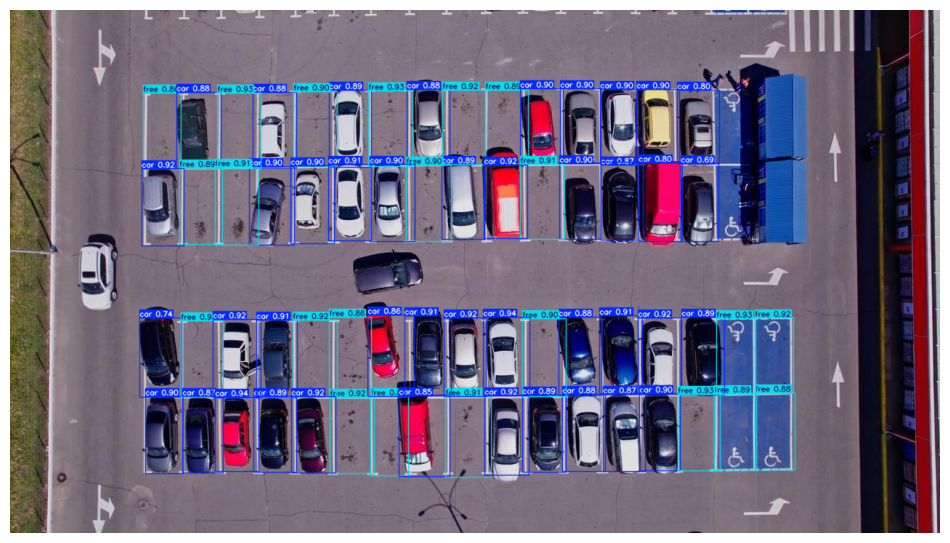

In [2]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load your YOLO model
model = YOLO("/kaggle/working/runs/detect/train-2/weights/best.pt")  # put your .pt file path here


image_path = "/kaggle/working/parking-lot-1/test/images/istock_1352323846-1-_mp4-0000_jpg.rf.bce605ef5e08a102a32eef3dd9da676a.jpg"

img = cv2.imread(image_path)

results = model(img, conf=0.5)

# Draw with smaller labels
output = results[0].plot(
    labels=True,
    boxes=True,
    line_width=1
)

output = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(output)
plt.axis("off")
plt.show()

In [3]:
model = YOLO("/kaggle/working/runs/detect/train-2/weights/best.pt")

In [4]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os

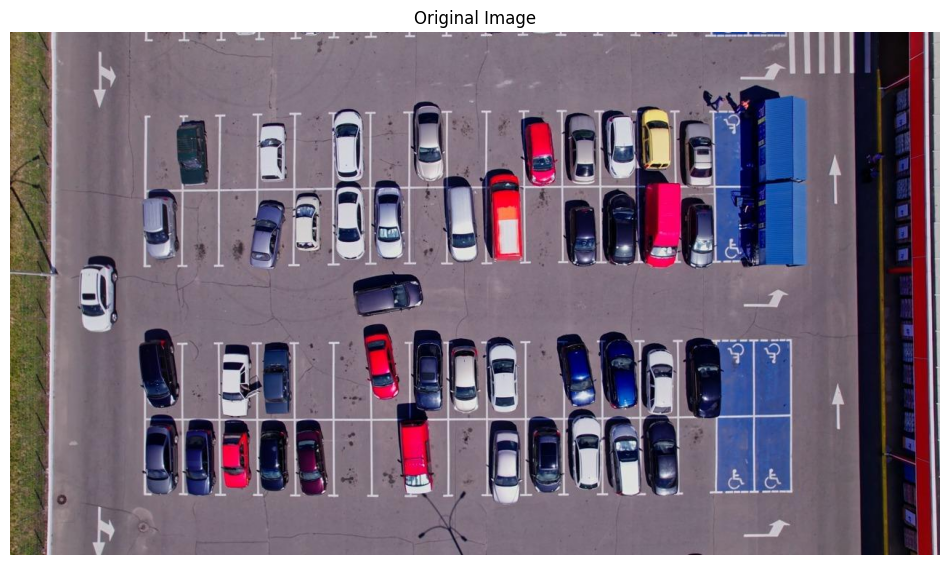

In [5]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread(image_path)

rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

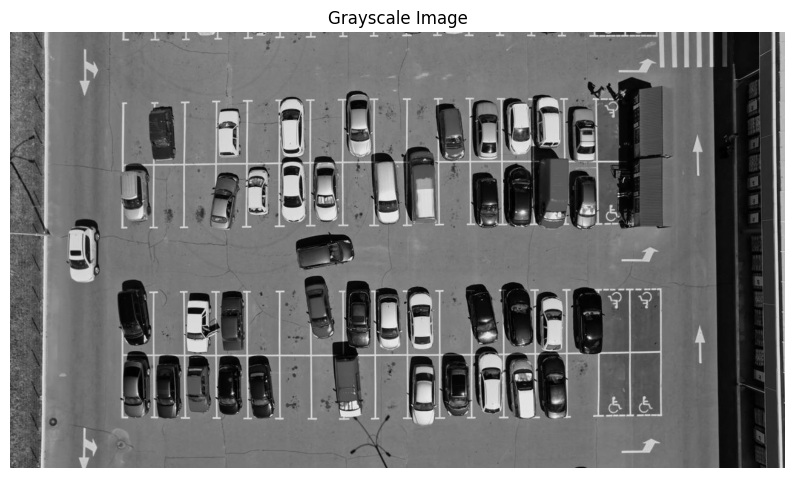

In [6]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10,8))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

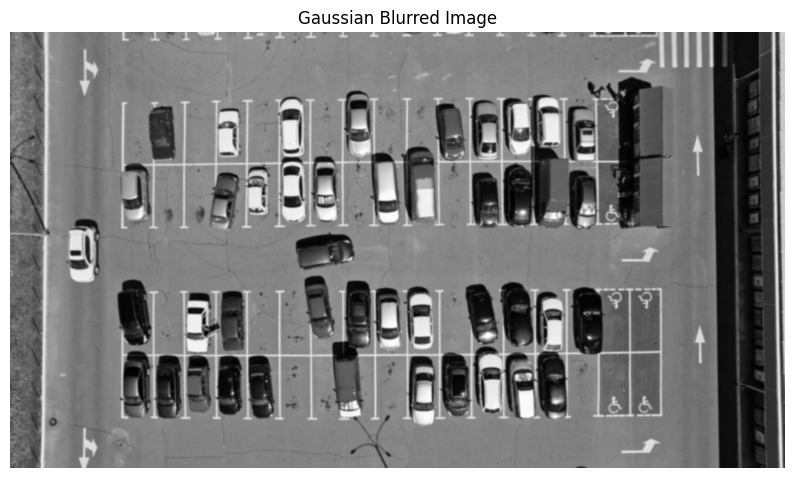

In [7]:
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.figure(figsize=(10,8))
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blurred Image")
plt.axis("off")
plt.show()

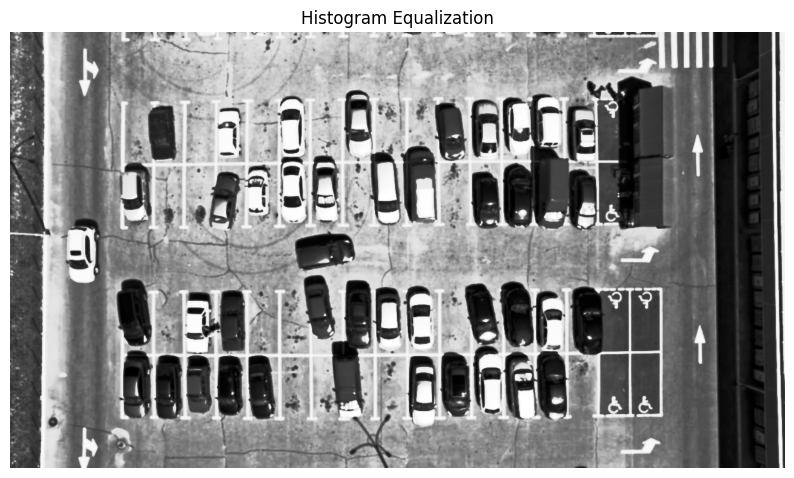

In [8]:
equalized = cv2.equalizeHist(blur)

plt.figure(figsize=(10,8))
plt.imshow(equalized, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")
plt.show()

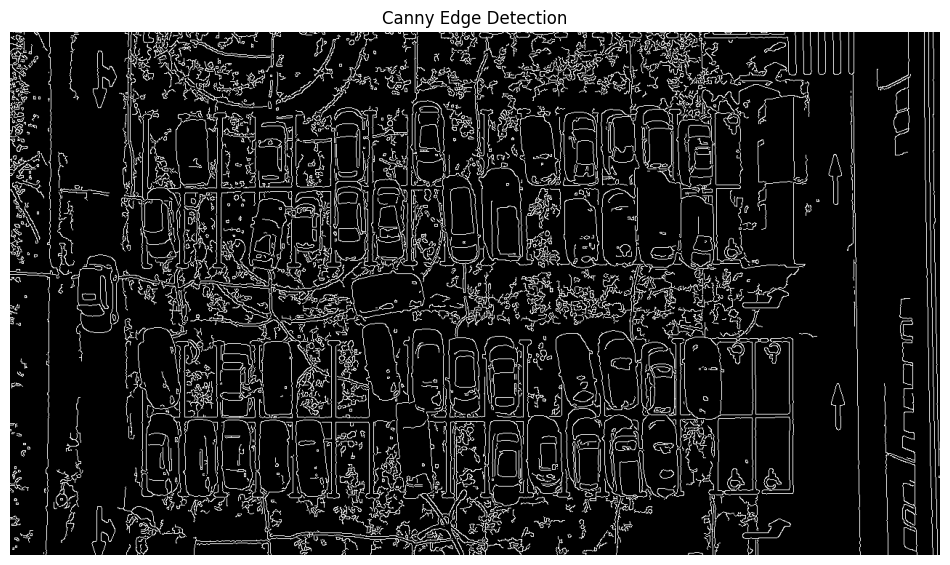

In [9]:
edges = cv2.Canny(
    equalized,
    threshold1=50,
    threshold2=150
)

plt.figure(figsize=(12,8))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

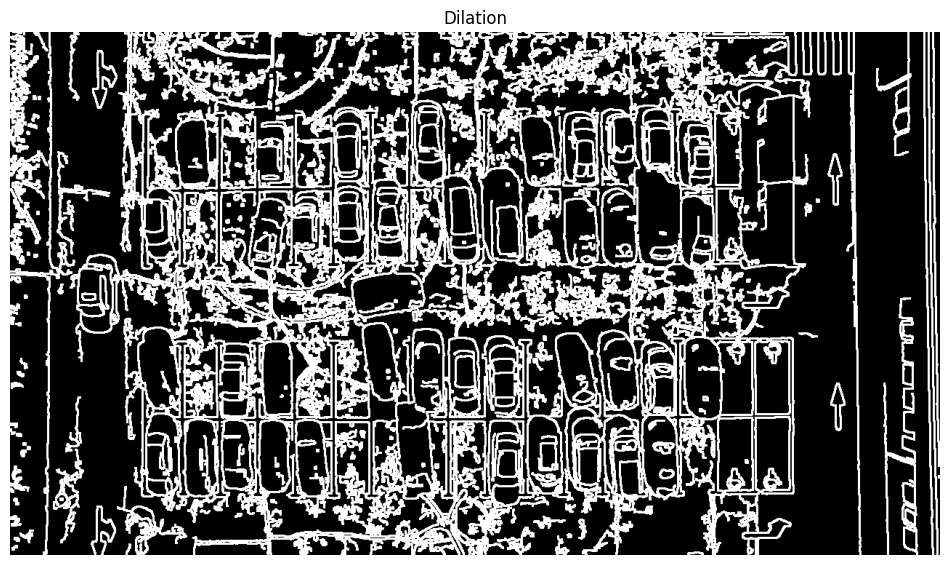

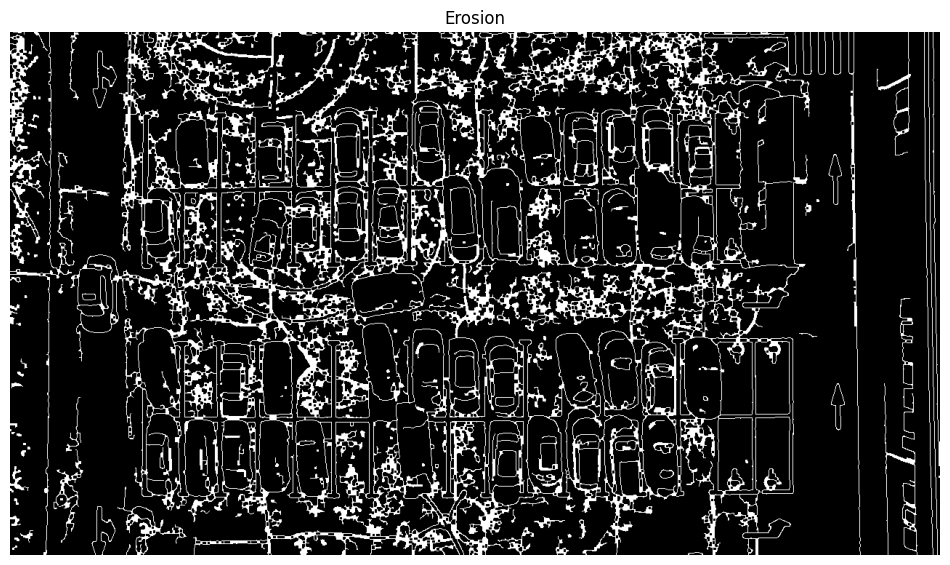

In [12]:
import numpy as np
kernel = np.ones((3,3), np.uint8)
dilation = cv2.dilate(
    edges,
    kernel,
    iterations=1
)

plt.figure(figsize=(12,8))
plt.imshow(dilation, cmap="gray")
plt.title("Dilation")
plt.axis("off")
plt.show()
erosion = cv2.erode(
    dilation,
    kernel,
    iterations=1
)

plt.figure(figsize=(12,8))
plt.imshow(erosion, cmap="gray")
plt.title("Erosion")
plt.axis("off")
plt.show()

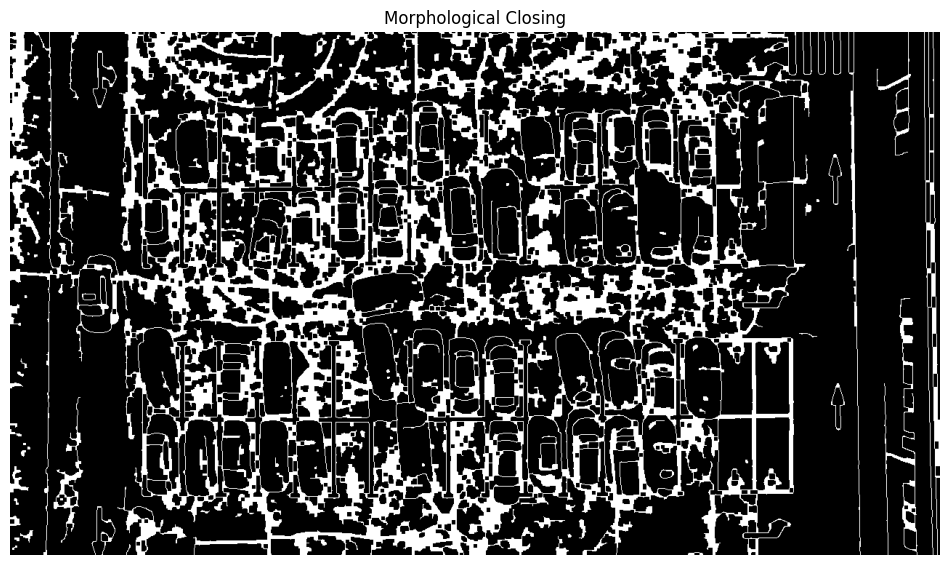

In [13]:
closing = cv2.morphologyEx(
    edges,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

plt.figure(figsize=(12,8))
plt.imshow(closing, cmap="gray")
plt.title("Morphological Closing")
plt.axis("off")
plt.show()

In [14]:
contours, hierarchy = cv2.findContours(
    closing,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print(f"Number of contours detected: {len(contours)}")

Number of contours detected: 69


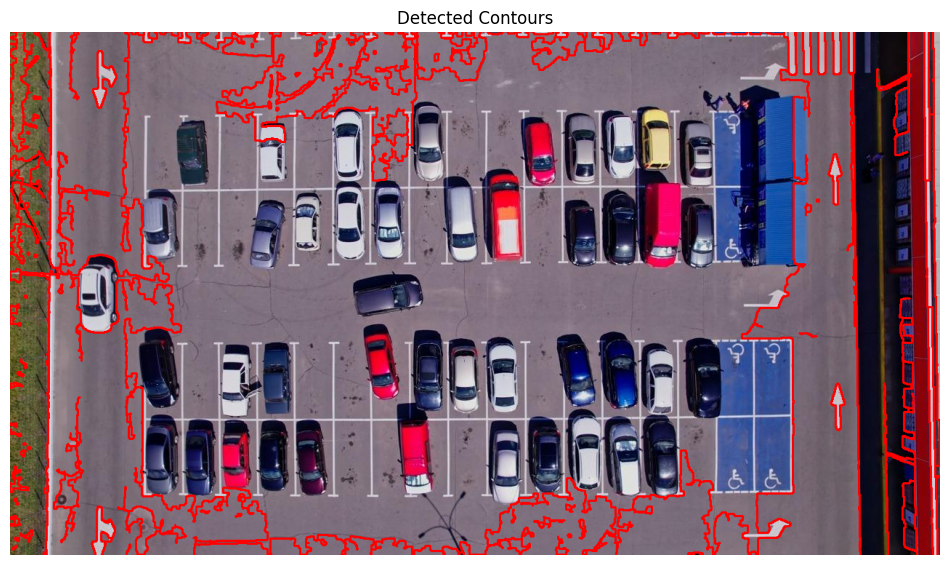

In [15]:
contour_img = rgb.copy()

cv2.drawContours(
    contour_img,
    contours,
    -1,
    (255, 0, 0),
    2
)

plt.figure(figsize=(12,8))
plt.imshow(contour_img)
plt.title("Detected Contours")
plt.axis("off")
plt.show()

In [16]:
shape_img = rgb.copy()

for cnt in contours:

    area = cv2.contourArea(cnt)

    # Ignore very small contours (noise)
    if area < 300:
        continue

    perimeter = cv2.arcLength(cnt, True)

    x, y, w, h = cv2.boundingRect(cnt)

    aspect_ratio = w / h

    cv2.rectangle(
        shape_img,
        (x, y),
        (x+w, y+h),
        (0, 255, 0),
        2
    )

    print("-"*40)
    print(f"Area         : {area:.2f}")
    print(f"Perimeter    : {perimeter:.2f}")
    print(f"Width        : {w}")
    print(f"Height       : {h}")
    print(f"Aspect Ratio : {aspect_ratio:.2f}")

----------------------------------------
Area         : 1660.00
Perimeter    : 497.08
Width        : 95
Height       : 94
Aspect Ratio : 1.01
----------------------------------------
Area         : 1336.50
Perimeter    : 693.20
Width        : 41
Height       : 200
Aspect Ratio : 0.20
----------------------------------------
Area         : 541.00
Perimeter    : 150.77
Width        : 19
Height       : 65
Aspect Ratio : 0.29
----------------------------------------
Area         : 2504.50
Perimeter    : 1586.80
Width        : 46
Height       : 353
Aspect Ratio : 0.13
----------------------------------------
Area         : 558.50
Perimeter    : 160.18
Width        : 19
Height       : 70
Aspect Ratio : 0.27
----------------------------------------
Area         : 511.50
Perimeter    : 675.61
Width        : 72
Height       : 140
Aspect Ratio : 0.51
----------------------------------------
Area         : 725.50
Perimeter    : 197.50
Width        : 49
Height       : 41
Aspect Ratio : 1.20
------

In [17]:
results = model.predict(
    image_path,
    conf=0.40,
    verbose=False
)

result = results[0]

In [18]:
output = rgb.copy()

occupied = 0
vacant = 0

In [19]:
for box in result.boxes:

    # Bounding box coordinates
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    # Class and confidence
    cls = int(box.cls[0])
    confidence = float(box.conf[0])

    label = model.names[cls]

    # ----------------------------
    # Geometric Analysis
    # ----------------------------

    width = x2 - x1
    height = y2 - y1
    area = width * height

    center_x = (x1 + x2) // 2
    center_y = (y1 + y2) // 2

    aspect_ratio = width / height

    # Ignore extremely small detections
    if area < 300:
        continue

    # ----------------------------
    # Decision Making
    # ----------------------------

    if label == "car":

        occupied += 1
        color = (255,0,0)      # Red

    else:

        vacant += 1
        color = (0,255,0)      # Green

    # Draw Bounding Box
    cv2.rectangle(
        output,
        (x1,y1),
        (x2,y2),
        color,
        2
    )

    # Draw Center Point
    cv2.circle(
        output,
        (center_x, center_y),
        4,
        (255,255,0),
        -1
    )

    # Label
    cv2.putText(
        output,
        label,
        (x1, y1-8),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        color,
        2
    )

    # Print Geometric Information
    print("="*40)
    print(f"Class        : {label}")
    print(f"Confidence   : {confidence:.2f}")
    print(f"Width        : {width}")
    print(f"Height       : {height}")
    print(f"Area         : {area}")
    print(f"Aspect Ratio : {aspect_ratio:.2f}")
    print(f"Center       : ({center_x}, {center_y})")

Class        : car
Confidence   : 0.94
Width        : 60
Height       : 102
Area         : 6120
Aspect Ratio : 0.59
Center       : (312, 584)
Class        : car
Confidence   : 0.94
Width        : 64
Height       : 107
Area         : 6848
Aspect Ratio : 0.60
Center       : (683, 476)
Class        : free
Confidence   : 0.93
Width        : 58
Height       : 105
Area         : 6090
Aspect Ratio : 0.55
Center       : (948, 581)
Class        : free
Confidence   : 0.93
Width        : 60
Height       : 104
Area         : 6240
Aspect Ratio : 0.58
Center       : (315, 167)
Class        : free
Confidence   : 0.93
Width        : 61
Height       : 104
Area         : 6344
Aspect Ratio : 0.59
Center       : (523, 164)
Class        : free
Confidence   : 0.93
Width        : 54
Height       : 104
Area         : 5616
Aspect Ratio : 0.52
Center       : (999, 477)
Class        : car
Confidence   : 0.92
Width        : 60
Height       : 101
Area         : 6060
Aspect Ratio : 0.59
Center       : (682, 264)
Cl

In [20]:
total_slots = occupied + vacant

occupancy_rate = (
    occupied / total_slots * 100
    if total_slots > 0
    else 0
)

cv2.putText(
    output,
    f"Total Slots : {total_slots}",
    (20,35),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255,255,255),
    2
)

cv2.putText(
    output,
    f"Occupied : {occupied}",
    (20,70),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255,0,0),
    2
)

cv2.putText(
    output,
    f"Vacant : {vacant}",
    (20,105),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (0,255,0),
    2
)

cv2.putText(
    output,
    f"Occupancy : {occupancy_rate:.1f}%",
    (20,140),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255,255,0),
    2
)

array([[[105,  83,  44],
        [ 93,  71,  32],
        [104,  82,  41],
        ...,
        [188, 182, 184],
        [187, 183, 182],
        [187, 183, 182]],

       [[104,  82,  43],
        [ 85,  63,  24],
        [ 87,  65,  24],
        ...,
        [188, 182, 184],
        [187, 183, 182],
        [187, 183, 182]],

       [[ 97,  75,  34],
        [ 86,  64,  23],
        [ 87,  65,  24],
        ...,
        [188, 182, 184],
        [187, 183, 182],
        [187, 183, 182]],

       ...,

       [[ 89,  87,  39],
        [ 67,  65,  17],
        [ 68,  64,  17],
        ...,
        [ 72,  40,  61],
        [ 72,  48,  70],
        [ 65,  48,  67]],

       [[113, 113,  63],
        [ 83,  83,  33],
        [ 71,  69,  21],
        ...,
        [ 73,  41,  62],
        [ 73,  49,  71],
        [ 67,  50,  69]],

       [[123, 125,  75],
        [ 92,  94,  44],
        [ 78,  76,  28],
        ...,
        [ 74,  42,  63],
        [ 73,  49,  71],
        [ 67,  50,  69]]

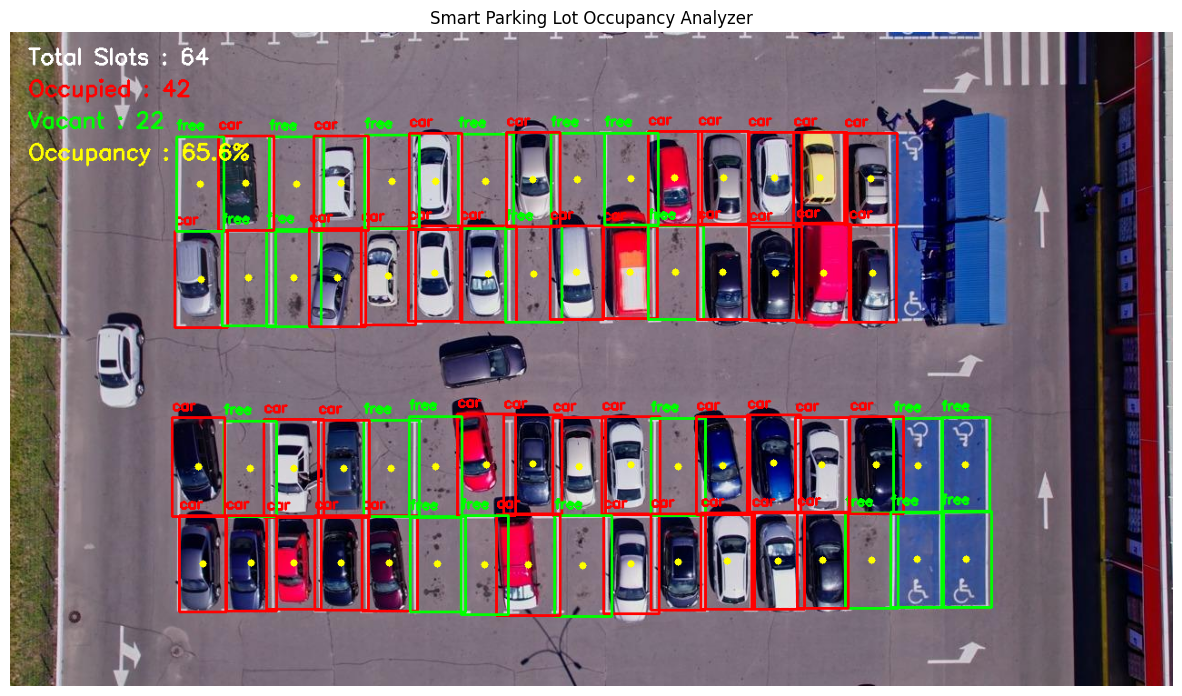

In [21]:
plt.figure(figsize=(15,10))
plt.imshow(output)
plt.title("Smart Parking Lot Occupancy Analyzer")
plt.axis("off")
plt.show()

In [22]:
test_dir = "/kaggle/working/parking-lot-1/test/images"

image_files = [
    os.path.join(test_dir, img)
    for img in os.listdir(test_dir)
    if img.endswith((".jpg", ".jpeg", ".png"))
]

print(f"Total Test Images: {len(image_files)}")

Total Test Images: 86


In [30]:
import random
random.seed(32)

sample_images = random.sample(image_files, 6)

sample_images

['/kaggle/working/parking-lot-1/test/images/istock_1369850483_mp4-0008_jpg.rf.91663da40396af46f0ace9c329b09ef7.jpg',
 '/kaggle/working/parking-lot-1/test/images/istock_1369850483_mp4-0031_jpg.rf.9a10f226ee16fbce3773d8c92cf314ba.jpg',
 '/kaggle/working/parking-lot-1/test/images/istock_1352323846_mp4-0004_jpg.rf.14993875c769bbd20189c1305fa83889.jpg',
 '/kaggle/working/parking-lot-1/test/images/istock_1352323846_mp4-0016_jpg.rf.e2cfb2a14f2c3db9968f410746abb988.jpg',
 '/kaggle/working/parking-lot-1/test/images/istock_1369850483_mp4-0025_jpg.rf.942f95d03075999a91fefbd126c39d47.jpg',
 '/kaggle/working/parking-lot-1/test/images/istock_1369850483_mp4-0000_jpg.rf.63ffa370df3be0094a0e37795f1aa973.jpg']

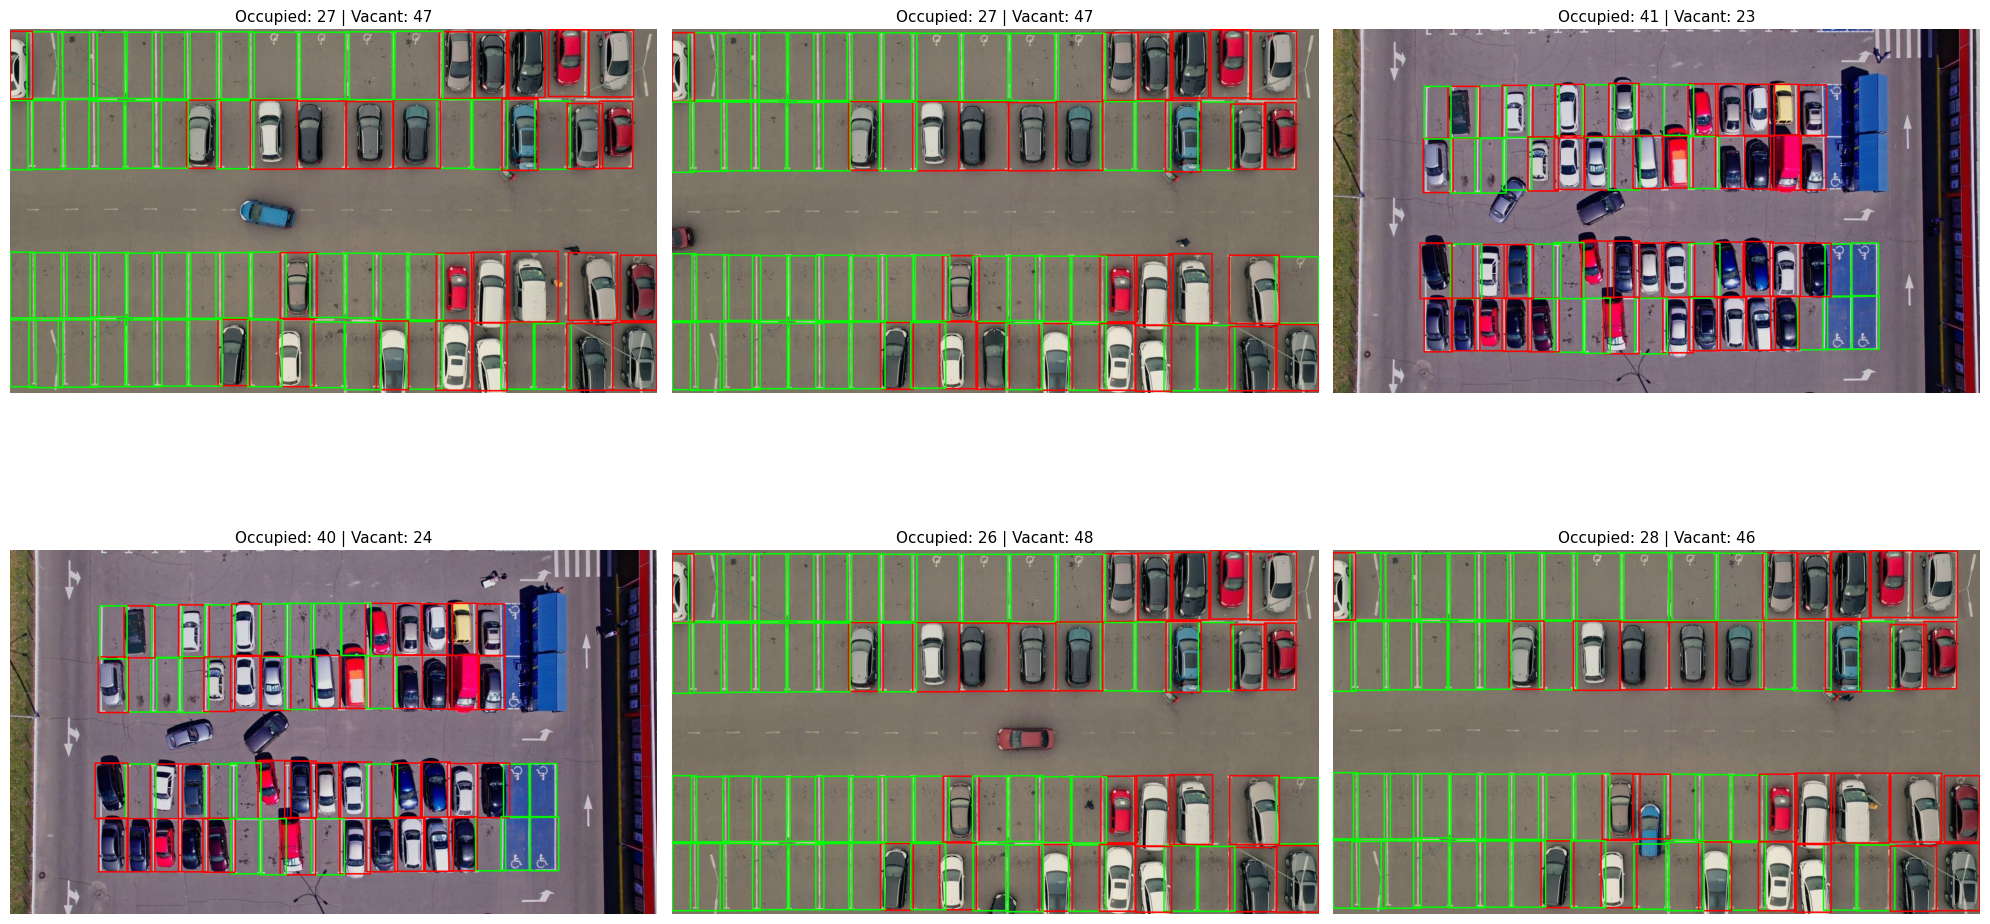

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for ax, image_path in zip(axes, sample_images):

    img = cv2.imread(image_path)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = model.predict(
        image_path,
        conf=0.4,
        verbose=False
    )

    result = results[0]

    occupied = 0
    vacant = 0

    for box in result.boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        cls = int(box.cls[0])
        label = model.names[cls]

        if label == "car":
            occupied += 1
            color = (255, 0, 0)
        else:
            vacant += 1
            color = (0, 255, 0)

        cv2.rectangle(rgb, (x1, y1), (x2, y2), color, 2)

    ax.imshow(rgb)
    ax.set_title(
        f"Occupied: {occupied} | Vacant: {vacant}",
        fontsize=11
    )
    ax.axis("off")

plt.tight_layout()
plt.show()